# 妨害名譽罪名分類專案 — 進度報告

最後更新：2026-09-29

這份 notebook 用圖表 + 白話說明兩階段的進度：

1. **抓資料**：從司法院判決書網站爬「妨害名譽」相關刑事判決
2. **訓練模型**：把抓到的資料整理成「一句網路留言 → 罪名」的分類任務，比較 5 個中文
   HuggingFace 模型的表現

> 目標：餵給模型一句網路留言（例如「你這個智障」），讓它猜出這句話構成
> `公然侮辱`、`加重誹謗`、`散布文字誹謗`、`誹謗`，還是最後被判`無罪`。

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

# 讓圖表能正常顯示繁體中文（Windows 內建的微軟正黑體）
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

ML_ROOT = Path.cwd() if Path.cwd().name == "ml" else Path.cwd() / "ml"
ROOT = ML_ROOT.parent


C:\Users\User\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 第一步：抓資料

爬蟲（`dataset/crawler_defamation.py`）去司法院判決書查詢系統，用「案由＝妨害名譽」查
刑事案件。網站一次查詢最多只給看 500 筆結果，所以爬蟲把判決日期切成一段一段去查，
確保每一段都在 500 筆以內，再把每一段的結果分別抓完。

抓到判決全文後，用兩種方法從裡面挖出「被告講了什麼話」跟「判了什麼罪」：

- **精準版**：如果判決書裡剛好附了檢察官起訴書的表格（日期/平台/帳號/內容/罪名都列好），
  就直接照表格一列一列抓，品質最好、也保有社交平台、帳號等完整資訊。
- **備用版**：大部分判決書沒有這種表格，只能改用比較粗的規則——去判決書裡找
  用「」括起來的句子當作是被告講的話，再從判決結果那句話裡用關鍵字比對抓出罪名
  （例如「...犯散布文字誹謗罪...」→ 抓出「散布文字誹謗」）。這個方法簡單但雜訊也比較多。

下圖是資料量在整個流程中的變化：

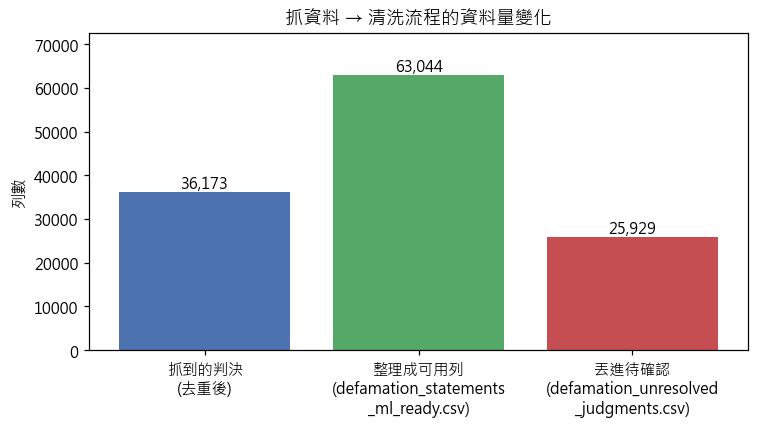

In [2]:
stages = {
    "抓到的判決\n(去重後)": 36_173,
    "整理成可用列\n(defamation_statements\n_ml_ready.csv)": 63_044,
    "丟進待確認\n(defamation_unresolved\n_judgments.csv)": 25_929,
}

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(stages.keys(), stages.values(), color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("列數")
ax.set_title("抓資料 → 清洗流程的資料量變化")
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{int(b.get_height()):,}",
            ha="center", va="bottom", fontsize=10)
ax.margins(y=0.15)
plt.tight_layout()
plt.show()


**怎麼讀這張圖**：一開始抓到 36,173 份不重複的判決書。因為每份判決書可能提到
好幾句被告講的話，經過兩種抓法整理後可用的資料列展開成 63,044 列（一列＝一句話 +
它的罪名）。另外有 25,929 列因為抓不到明確的言論內容或罪名，先放進「待確認」，
不會拿去訓練模型（寧可少用一點資料，也不要用猜的去填空）。

## 第二步：訓練模型分類

### 2.1 先把標籤縮減到 5 種

原始資料裡「罪名」欄位寫法五花八門，一共有 102 種不同的字串，其中很多根本不是罪名，
是判決的「程序性結果」，例如：

- `上訴駁回。`
- `原告之訴駁回。`
- `再審之聲請駁回。`

這次任務只挑 5 種目標標籤：`公然侮辱`、`加重誹謗`、`散布文字誹謗`、`誹謗`、`無罪`。

### 2.2 三個清洗步驟（缺一不可）

1. **去重複** — 爬蟲是可以中斷續抓的設計，重跑常常會抓到一樣的句子，34% 的列是完全
   重複，直接刪除。
2. **丟棄「一句話對到好幾種罪名」的矛盾資料** — 備用版抓法會把判決書裡任何「」引號
   內容都當作是被告講的話，結果連判決書的法律固定用語（例如「意圖散布於眾」）都被
   當成言論抓進來，同一句法律套語會同時掛在好幾種不同罪名下。這種矛盾資料代表它根本
   不是真的網路留言，整批刪除，不亂猜一個標籤給它。
3. **刪掉太短的碎句** — 少於 6 個字的殘留片段（像「同仁」、「、」）沒有語意可判斷。

### 2.3 切資料時最容易犯的錯：不能用「隨機」切

清洗完剩下的句子，只來自 6,990 份判決書，而同一份判決書拆出來的句子往往內容很像、
標籤也一樣。如果隨機把資料切成「訓練用」跟「考試用」，同一份判決的句子可能一邊一句，
AI 會靠「背這份判決長怎樣」拿高分，而不是真的學會判斷語意——分數會虛高，沒有參考價值。

解法：改用「整份判決」當作切分單位，確保同一份判決的句子只會出現在訓練或考試其中一邊，
不會同時出現在兩邊。

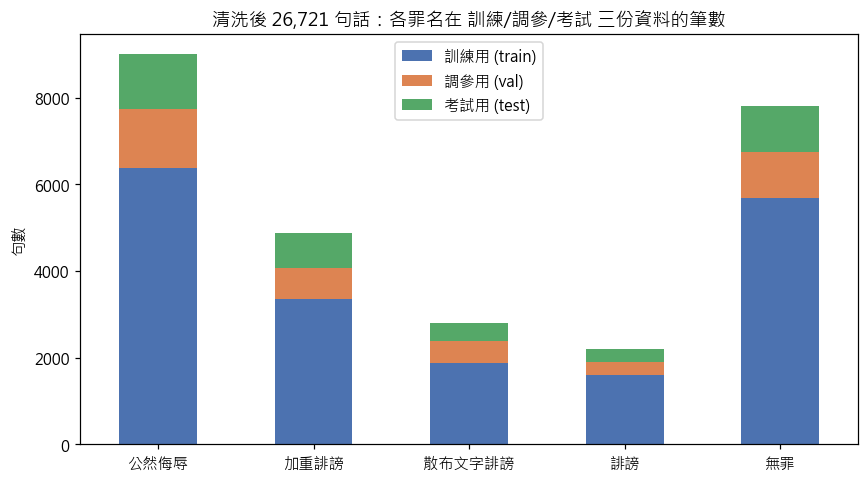

總計 26,721 句，來自 6,990 份判決
        train   val  test    合計
涉犯罪名                           
公然侮辱     6385  1361  1268  9014
加重誹謗     3352   722   812  4886
散布文字誹謗   1870   517   423  2810
誹謗       1594   316   292  2202
無罪       5674  1078  1057  7809


In [3]:
label_map = json.loads((ML_ROOT / "data" / "label_map.json").read_text(encoding="utf-8"))
labels = label_map["labels"]

splits = {
    name: pd.read_csv(ML_ROOT / "data" / f"{name}.csv", encoding="utf-8-sig")
    for name in ("train", "val", "test")
}

counts = pd.DataFrame({
    name: df["涉犯罪名"].value_counts().reindex(labels).fillna(0).astype(int)
    for name, df in splits.items()
})
counts = counts.reindex(labels)

fig, ax = plt.subplots(figsize=(8, 4.5))
counts.plot(kind="bar", stacked=True, ax=ax,
            color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title("清洗後 26,721 句話：各罪名在 訓練/調參/考試 三份資料的筆數")
ax.set_ylabel("句數")
ax.set_xlabel("")
ax.legend(["訓練用 (train)", "調參用 (val)", "考試用 (test)"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"總計 {counts.values.sum():,} 句，來自 6,990 份判決")
print(counts.assign(合計=counts.sum(axis=1)))


**怎麼讀這張圖**：`公然侮辱` 跟 `無罪` 這兩類資料量最多，`誹謗` 最少——這是真實
世界的類別不平衡，不是切分造成的。後面評分時會用「macro-F1」而不是單純的猜中率，
避免分數被資料量最多的兩類主導。

### 2.4 選哪些模型來比較

去 HuggingFace（AI 模型下載平台）用**下載量**排序，分兩組各挑幾個：

- **通用中文模型 Top 3**：不限定領域，下載量最高的中文文本模型
- **法律領域模型 Top 2**：專門拿法律/判決書文字訓練過的中文模型，下載量最高的兩個

後兩個的目的是驗證一個假設：「AI 有沒有讀過法律文件，猜罪名會不會比較準？」

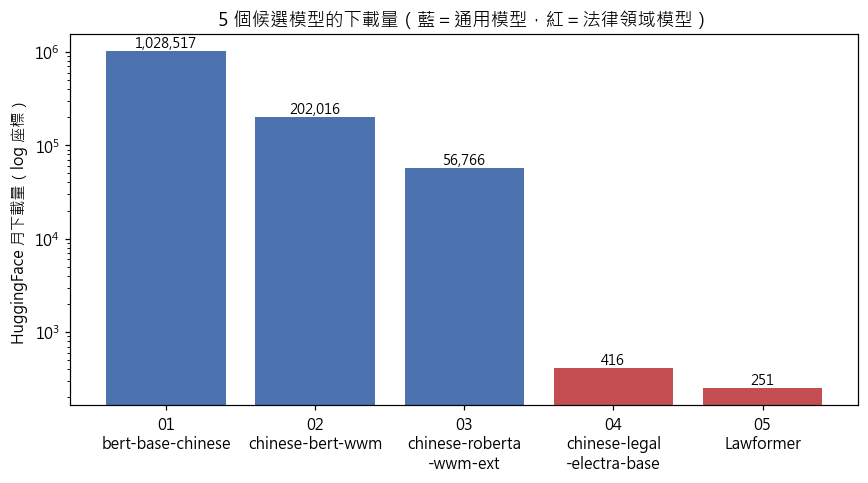

In [4]:
hf_downloads = {
    "01\nbert-base-chinese": 1_028_517,
    "02\nchinese-bert-wwm": 202_016,
    "03\nchinese-roberta\n-wwm-ext": 56_766,
    "04\nchinese-legal\n-electra-base": 416,
    "05\nLawformer": 251,
}
group_color = ["#4C72B0"] * 3 + ["#C44E52"] * 2

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(hf_downloads.keys(), hf_downloads.values(), color=group_color)
ax.set_yscale("log")
ax.set_ylabel("HuggingFace 月下載量（log 座標）")
ax.set_title("5 個候選模型的下載量（藍＝通用模型，紅＝法律領域模型）")
for i, v in enumerate(hf_downloads.values()):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


**怎麼讀這張圖**：注意 y 軸是 log（對數）座標——法律領域模型的下載量比通用模型
低了整整三個數量級（幾百 vs 幾十萬到上百萬）。這不代表法律模型不好，而是中文法律
NLP 這個小眾領域的預訓練生態本來就小，這兩個已經是 HuggingFace 上的天花板。

## 3. 訓練結果

評分用的是 **macro-F1**：5 個罪名各自算一個猜中率分數，再取平均，不會因為
「公然侮辱」跟「無罪」筆數多就佔便宜。滿分 1，越高越準。

> 目前 5 個模型中，Lawformer（05）序列較長、batch 較小，訓練時間也比其他 4 個久，
> 若這裡看到它缺席，代表當時還在跑；重新執行這個 notebook 就會補上。

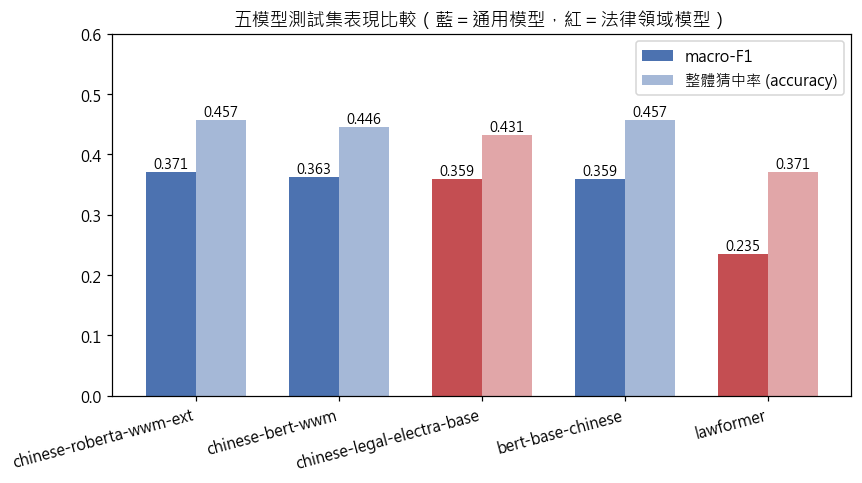

In [5]:
GROUP = {
    "01_bert-base-chinese": "通用",
    "02_chinese-bert-wwm": "通用",
    "03_chinese-roberta-wwm-ext": "通用",
    "04_chinese-legal-electra-base": "法律",
    "05_lawformer": "法律",
}

results = {}
for folder in GROUP:
    p = ML_ROOT / folder / "results.json"
    if p.exists():
        results[folder] = json.loads(p.read_text(encoding="utf-8"))

missing = [f for f in GROUP if f not in results]
if missing:
    print("尚未完成、圖表中會缺席：", missing)

order = sorted(results, key=lambda f: results[f]["test_macro_f1"], reverse=True)
macro_f1 = [results[f]["test_macro_f1"] for f in order]
acc = [results[f]["test_accuracy"] for f in order]
colors = ["#4C72B0" if GROUP[f] == "通用" else "#C44E52" for f in order]

x = np.arange(len(order))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width / 2, macro_f1, width, label="macro-F1", color=colors)
ax.bar(x + width / 2, acc, width, label="整體猜中率 (accuracy)", color=colors, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels([f.split("_", 1)[1] for f in order], rotation=15, ha="right")
ax.set_ylim(0, 0.6)
ax.set_title("五模型測試集表現比較（藍＝通用模型，紅＝法律領域模型）")
ax.legend()
for i, (m, a) in enumerate(zip(macro_f1, acc)):
    ax.text(i - width / 2, m, f"{m:.3f}", ha="center", va="bottom", fontsize=9)
    ax.text(i + width / 2, a, f"{a:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


**怎麼讀這張圖**：目前分數都落在 0.36～0.37 之間（macro-F1），差異不算大。
比較意外的是「有讀過法律文件的 AI」(legal-electra) 並沒有比普通 AI 準，甚至還略輸
`chinese-roberta-wwm-ext`——可能原因是法律模型是拿「判決書全文」的書面文體訓練的，
但這次要猜的是「網路留言」的口語、髒話、諧音字，兩種文體落差太大，法律知識沒有
派上用場。

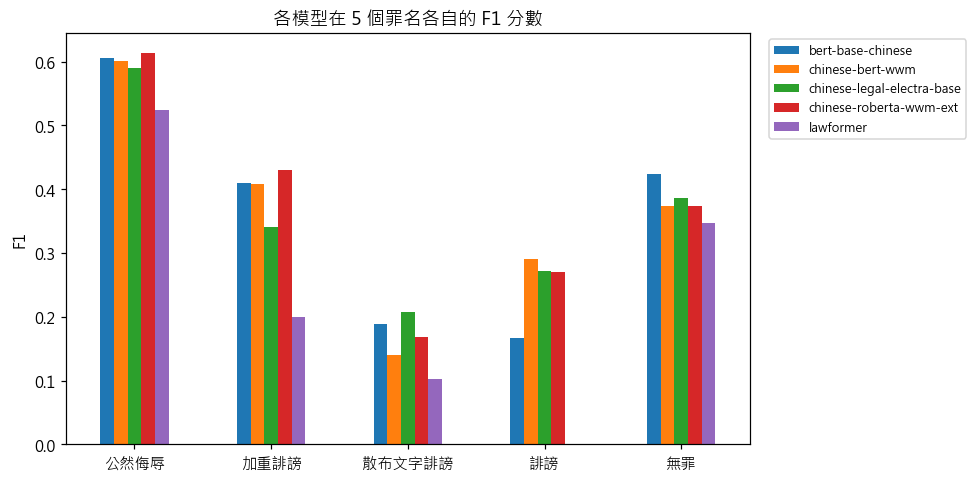

In [6]:
rows = []
for f in order:
    r = results[f]
    for label, f1 in r["per_class_f1"].items():
        rows.append({"模型": f.split("_", 1)[1], "罪名": label, "F1": f1})
pcf = pd.DataFrame(rows).pivot(index="罪名", columns="模型", values="F1").reindex(labels)

fig, ax = plt.subplots(figsize=(9, 4.5))
pcf.plot(kind="bar", ax=ax)
ax.set_title("各模型在 5 個罪名各自的 F1 分數")
ax.set_ylabel("F1")
ax.set_xlabel("")
plt.xticks(rotation=0)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


**怎麼讀這張圖**：每個模型都是同樣的規律——`公然侮辱` 最準（F1 約 0.5～0.6），
`誹謗` 跟 `散布文字誹謗` 最不準（F1 常常只有 0.2 上下）。這不是模型不夠好，而是
`加重誹謗` / `散布文字誹謗` / `誹謗` 這三個類別在刑法上其實是**同一條法條（刑法 310 條）
的不同講法**，連寫判決書的法官用詞都不完全一致，AI 分不清楚三者的界線是合理的。

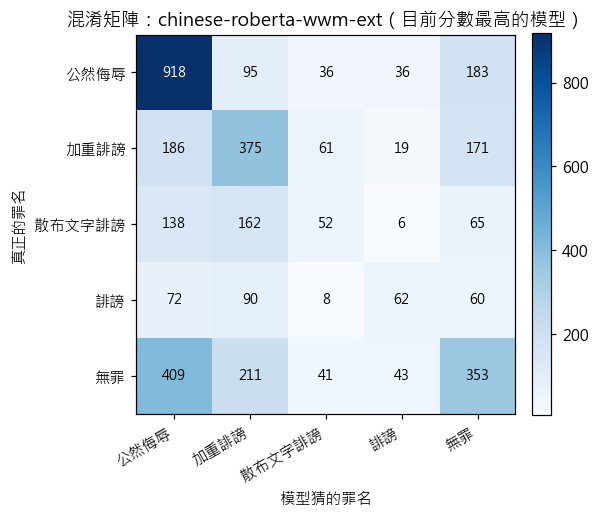

In [7]:
best = order[0]
cm = np.array(results[best]["confusion_matrix"])

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_yticklabels(labels)
ax.set_xlabel("模型猜的罪名")
ax.set_ylabel("真正的罪名")
ax.set_title(f"混淆矩陣：{best.split('_', 1)[1]}（目前分數最高的模型）")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=9)
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


**怎麼讀這張圖（混淆矩陣）**：對角線（左上到右下）是「猜對」的數量，顏色越深、
數字越大代表猜對越多。看橫排就能看出每個真實罪名最常被誤判成什麼——如果你看到
`加重誹謗`那一列在`散布文字誹謗`欄位、`誹謗`那一列在`加重誹謗`欄位的數字也不小，
就印證了前面說的：這三類彼此界線模糊，模型常常在這三者之間猜錯，但很少會把
`公然侮辱`跟這三類搞混（因為公然侮辱的語意——罵髒話、貶低人格——跟誹謗類需要的
「指摘具體事實」語意差很多）。

## 4. 結論與已知限制

- 5 個模型分數接近，`chinese-roberta-wwm-ext` 目前領先，但法律領域模型並沒有
  展現預期中的優勢——可能是訓練語料的文體（判決書全文 vs 網路口語留言）落差太大。
- 真正拉低整體分數的是 `加重誹謗` / `散布文字誹謗` / `誹謗` 三類彼此糾纏，這是
  **標籤定義本身的問題**，不是模型能力問題。下一步可以試著把這三類合併成一類，
  驗證分數會不會明顯回升。
- `無罪` 這個標籤代表的是「判決結果」而非言論本身的性質，同一句話可能因為證據不足
  被判無罪，言論內容本身不一定帶有可學的訊號，這類的分數預期本來就會偏低。
- 目前 63,044 筆可用資料裡，只有 176 筆來自最高品質的「起訴書表格」抓法，其餘都是
  備用規則抓出來的，缺少日期/平台/帳號等額外資訊可以當作模型特徵使用。

原始檔案位置：
- 抓資料：`dataset/crawler_defamation.py`、`dataset/clean_dataset.py`
- 訓練模型：`ml/prepare_data.py`、`ml/common.py`、`ml/0X_*/train.py`
- 完整表格版比較：`ml/RESULTS.md`

## 5. 追加實驗：把三個誹謗類罪名合併成一類

上面第 4 節的結論提到：拉低分數的主因是 `加重誹謗` / `散布文字誹謗` / `誹謗` 三類
彼此糾纏，而這三類在刑法上其實同屬**第 310 條**的不同講法。這一節驗證：如果把這三類
合併成一個「誹謗類」，分數會不會回升？

**這是一份完全獨立、不覆寫上面任何結果的追加實驗**：
- 資料準備：新檔案 `ml/prepare_data_merged.py` → 新目錄 `ml/data_merged/`
  （原本的 `ml/prepare_data.py`、`ml/data/` 完全沒動）
- 模型訓練：新資料夾 `ml/06`～`ml/10`，模型與超參數逐一對應原本的 `01`～`05`，
  只換資料來源，方便兩組結果直接對照
- 標籤合併規則：`加重誹謗`／`散布文字誹謗`／`誹謗` → 統一改叫 `誹謗類`；
  `公然侮辱`、`無罪` 不變

合併後還多回收了一批資料——原本 5 類任務裡「一句話被貼過不只一種細分標籤」
（例如同一句話曾同時被標成`加重誹謗`和`誹謗`）的矛盾資料會被整批丟棄；合併之後
這兩個標籤都變成`誹謗類`，不再矛盾，可以留下來用。因此可用列數從 26,721 筆
回升到 27,088 筆。

> 訓練佇列會接在第 4 節的 5 個模型之後自動執行（同一張 GPU 沒辦法同時跑兩個任務）。
> 如果下面圖表顯示「尚未有結果」，代表訓練還在背景進行，重新執行這個 notebook
> 就會補上。

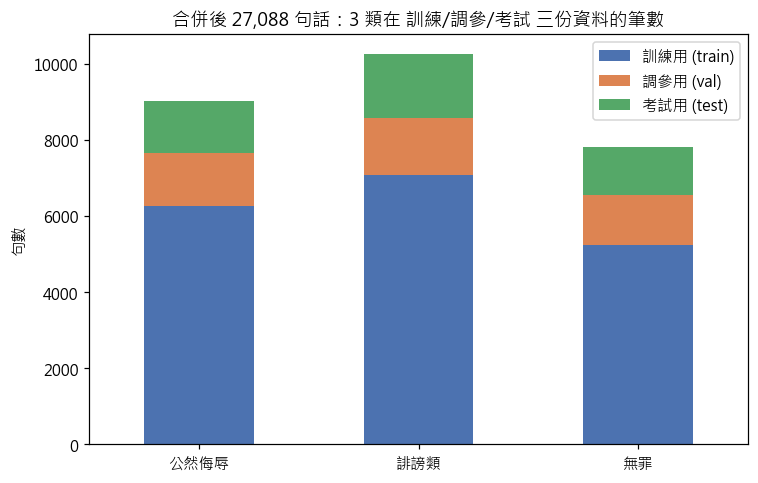

總計 27,088 句，來自 7,048 份判決（3 個 split 各自的判決數相加）
      train   val  test     合計
涉犯罪名                          
公然侮辱   6259  1388  1367   9014
誹謗類    7089  1478  1698  10265
無罪     5242  1318  1249   7809


In [8]:
merged_label_map = json.loads((ML_ROOT / "data_merged" / "label_map.json").read_text(encoding="utf-8"))
merged_labels = merged_label_map["labels"]

merged_splits = {
    name: pd.read_csv(ML_ROOT / "data_merged" / f"{name}.csv", encoding="utf-8-sig")
    for name in ("train", "val", "test")
}

merged_counts = pd.DataFrame({
    name: df["涉犯罪名"].value_counts().reindex(merged_labels).fillna(0).astype(int)
    for name, df in merged_splits.items()
}).reindex(merged_labels)

fig, ax = plt.subplots(figsize=(7, 4.5))
merged_counts.plot(kind="bar", stacked=True, ax=ax,
                    color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title(f"合併後 {merged_counts.values.sum():,} 句話：3 類在 訓練/調參/考試 三份資料的筆數")
ax.set_ylabel("句數")
ax.set_xlabel("")
ax.legend(["訓練用 (train)", "調參用 (val)", "考試用 (test)"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"總計 {merged_counts.values.sum():,} 句，來自 {merged_splits['train']['原文網址'].nunique() + merged_splits['val']['原文網址'].nunique() + merged_splits['test']['原文網址'].nunique():,} 份判決（3 個 split 各自的判決數相加）")
print(merged_counts.assign(合計=merged_counts.sum(axis=1)))


**怎麼讀這張圖**：三類的資料量比原本 5 類均衡不少——`誹謗類`（合併後）筆數變成最多，
跟`公然侮辱`、`無罪`落在同一個量級，不再是資料量最少的類別。

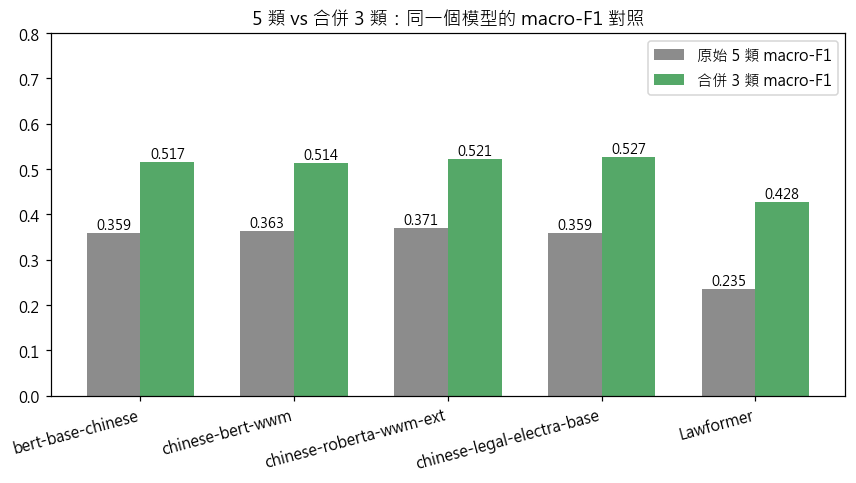

In [9]:
MERGED_PAIRS = [
    ("01_bert-base-chinese", "06_bert-base-chinese_merged", "bert-base-chinese"),
    ("02_chinese-bert-wwm", "07_chinese-bert-wwm_merged", "chinese-bert-wwm"),
    ("03_chinese-roberta-wwm-ext", "08_chinese-roberta-wwm-ext_merged", "chinese-roberta-wwm-ext"),
    ("04_chinese-legal-electra-base", "09_chinese-legal-electra-base_merged", "chinese-legal-electra-base"),
    ("05_lawformer", "10_lawformer_merged", "Lawformer"),
]


def _load(folder):
    p = ML_ROOT / folder / "results.json"
    return json.loads(p.read_text(encoding="utf-8")) if p.exists() else None


pair_results = [(name, _load(o), _load(m)) for o, m, name in MERGED_PAIRS]
done_pairs = [(name, o, m) for name, o, m in pair_results if m is not None]
pending = [name for name, o, m in pair_results if m is None]

if pending:
    print("合併標籤實驗尚未完成、圖表中會缺席：", pending)

if not done_pairs:
    print("目前還沒有任何合併標籤實驗的結果，訓練仍在背景進行中。")
else:
    names = [n for n, o, m in done_pairs]
    orig_f1 = [o["test_macro_f1"] if o else np.nan for n, o, m in done_pairs]
    merged_f1 = [m["test_macro_f1"] for n, o, m in done_pairs]

    x = np.arange(len(names))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(x - width / 2, orig_f1, width, label="原始 5 類 macro-F1", color="#8C8C8C")
    ax.bar(x + width / 2, merged_f1, width, label="合併 3 類 macro-F1", color="#55A868")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, ha="right")
    ax.set_ylim(0, 0.8)
    ax.set_title("5 類 vs 合併 3 類：同一個模型的 macro-F1 對照")
    ax.legend()
    for i, (o, m) in enumerate(zip(orig_f1, merged_f1)):
        if not np.isnan(o):
            ax.text(i - width / 2, o, f"{o:.3f}", ha="center", va="bottom", fontsize=9)
        ax.text(i + width / 2, m, f"{m:.3f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()


**怎麼判讀這張圖**：
- 如果綠色（合併 3 類）明顯高於灰色（原始 5 類），代表拉低分數的真的是「標籤切得太細」，
  下游應用把細分罪名拿掉、只判斷「有沒有構成誹謗類」會更實際可用。
- 如果合併後分數沒什麼變化，代表混淆不只是標籤粒度的問題，可能是「誹謗」需要的
  「指摘具體事實」語意本身，從單句留言就很難判斷。

本節會在背景訓練完成後自動補上完整的每類別 F1 與結論；目前先看上面的圖表有沒有資料。

## 6. 運行時間與資源使用比較

除了準確度，實際挑模型時也要考慮「訓練要等多久、吃多少 GPU 記憶體」。
這台機器是 RTX 4060（8GB VRAM）。

> `01`～`05` 訓練時計時功能還沒寫進 `common.py`，這裡的耗時是從訓練佇列自己印出的
> START/DONE 時間戳回推的（檔案的修改時間在這台機器上會被背景程式整批重寫，不可靠，
> 已經踩過一次坑，改用文字紀錄回推）；`06`～`10`（合併標籤版，跟 `01`～`05` 用同一組
> 模型和超參數）是加了計時之後訓練的，有實測的 GPU 峰值記憶體可以參考。

                            耗時(分鐘)  峰值GPU記憶體(GB)  參數量(M)
模型                                                      
bert-base-chinese             6.93          4.52  102.28
chinese-bert-wwm              6.87          4.52  102.28
chinese-roberta-wwm-ext       6.85          4.52  102.28
chinese-legal-electra-base    6.77          4.52  102.27
Lawformer                   202.98          2.28  126.37


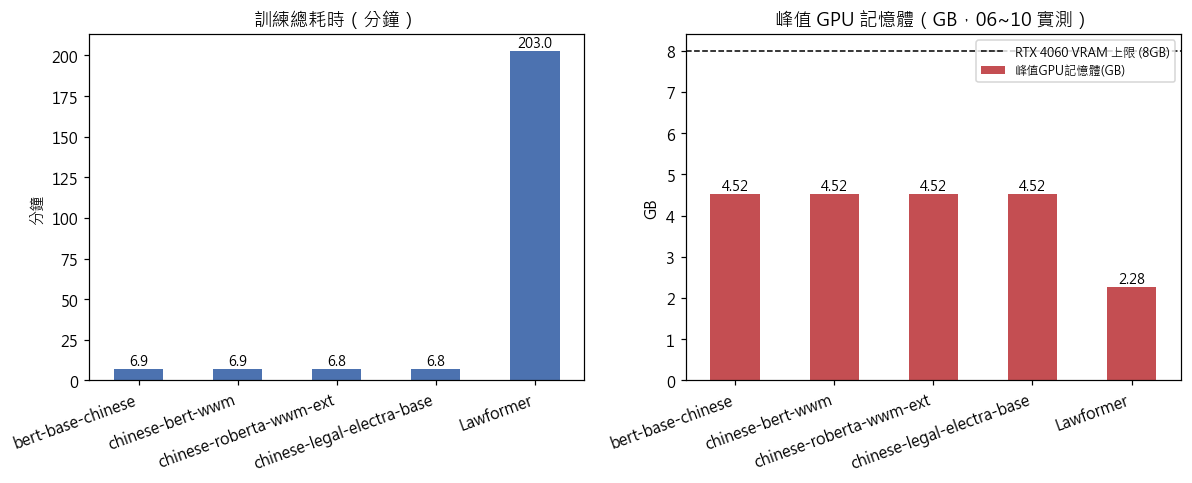

In [10]:
TIMING_PAIRS = [
    ("01_bert-base-chinese", "06_bert-base-chinese_merged", "bert-base-chinese"),
    ("02_chinese-bert-wwm", "07_chinese-bert-wwm_merged", "chinese-bert-wwm"),
    ("03_chinese-roberta-wwm-ext", "08_chinese-roberta-wwm-ext_merged", "chinese-roberta-wwm-ext"),
    ("04_chinese-legal-electra-base", "09_chinese-legal-electra-base_merged", "chinese-legal-electra-base"),
    ("05_lawformer", "10_lawformer_merged", "Lawformer"),
]

timing_rows = []
for orig_folder, merged_folder, name in TIMING_PAIRS:
    orig = _load(orig_folder)
    merged = _load(merged_folder)
    wall = (orig or {}).get("total_wall_clock_seconds")
    mem = (merged or {}).get("peak_gpu_memory_allocated_mb")  # 06~10 才有實測記憶體
    params = (orig or merged or {}).get("num_parameters")
    timing_rows.append({"模型": name, "耗時(分鐘)": wall / 60 if wall else np.nan,
                         "峰值GPU記憶體(GB)": mem / 1024 if mem else np.nan,
                         "參數量(M)": params / 1e6 if params else np.nan})

timing_df = pd.DataFrame(timing_rows).set_index("模型")
print(timing_df.round(2))

if timing_df["耗時(分鐘)"].notna().any():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    timing_df["耗時(分鐘)"].plot(kind="bar", ax=axes[0], color="#4C72B0")
    axes[0].set_title("訓練總耗時（分鐘）")
    axes[0].set_ylabel("分鐘")
    axes[0].set_xlabel("")
    for i, v in enumerate(timing_df["耗時(分鐘)"]):
        if not np.isnan(v):
            axes[0].text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)

    if timing_df["峰值GPU記憶體(GB)"].notna().any():
        timing_df["峰值GPU記憶體(GB)"].plot(kind="bar", ax=axes[1], color="#C44E52")
        axes[1].set_title("峰值 GPU 記憶體（GB，06~10 實測）")
        axes[1].set_ylabel("GB")
        axes[1].set_xlabel("")
        axes[1].axhline(8, color="black", linestyle="--", linewidth=1, label="RTX 4060 VRAM 上限 (8GB)")
        axes[1].legend(fontsize=8)
        for i, v in enumerate(timing_df["峰值GPU記憶體(GB)"]):
            if not np.isnan(v):
                axes[1].text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    else:
        axes[1].text(0.5, 0.5, "合併標籤實驗（06~10）\n尚未完成，暫無實測記憶體數據",
                     ha="center", va="center", transform=axes[1].transAxes)
        axes[1].axis("off")

    for ax in axes:
        plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("尚無耗時資料可畫圖。")


**怎麼讀這兩張圖**：
- 左圖是訓練一次要等多久。四個 base 尺寸模型（bert-base-chinese / chinese-bert-wwm /
  chinese-roberta-wwm-ext / chinese-legal-electra-base）耗時應該很接近——它們參數量
  相同（102M）、輸入長度和 batch size 也相同，差異主要來自模型架構細節。
  Lawformer 因為用了 2 倍的輸入長度（512 vs 256）、batch size 只有 1/4（8 vs 32），
  預期會明顯拉長。
- 右圖是峰值 GPU 記憶體，虛線是這台機器 RTX 4060 的 8GB 上限——如果某個模型的柱子
  接近或超過這條線，代表這組 batch size／長度設定已經逼近這張顯卡的極限，
  之後想加大 batch size 得先降別的參數。Lawformer 已經另外開了 gradient
  checkpointing（用計算時間換記憶體）才有辦法在 8GB 卡上跑 512 長度。
- 實務上選模型不能只看 macro-F1：如果 `chinese-roberta-wwm-ext` 分數最高、
  又跟其他 base 模型耗時差不多，那是明確的首選；但如果 Lawformer 的分數優勢
  必須靠數倍的訓練時間換來，這筆帳值不值得就要看實際部署的時間/資源預算。